# Day 108 — Decision Trees + Random Forest
**Month 6 | Week 3 | ML Foundations | 80 Points + 10★ Bonus**

---

### Business Scenario
You built a **logistic regression churn model** yesterday — it performed well, but your client asks:
> *"Can we do better? And more importantly — which customer behaviours actually drive churn? I want to see the logic, not just a probability."*

This is where tree-based models shine.

- **Decision Tree** → explainable, visual rules ("if inactive > 60 days AND orders < 3, then churn = 1")
- **Random Forest** → better accuracy + built-in feature importance ranking

**Your job today:** Train both models on the same ShopEase churn dataset, compare them against yesterday's logistic regression baseline, extract feature importances, and deliver a business recommendation the client can act on.

---

### Why Decision Trees + Random Forest?

| Model | Strength | Weakness |
|-------|----------|----------|
| Logistic Regression | Fast, interpretable coefficients | Assumes linear decision boundary |
| Decision Tree | Fully explainable rules, handles non-linearity | Overfits easily (memorises training data) |
| Random Forest | High accuracy, resistant to overfitting, feature ranking | Less interpretable (ensemble of 100+ trees) |

**Key insight:** Random Forest fixes Decision Tree's main flaw (overfitting) by averaging across many different trees trained on random data subsets. This is called **bagging** (Bootstrap Aggregating).

---

### Sections
| Section | Topic | Points |
|---------|-------|--------|
| **A** | Data Setup + Decision Tree Fit | 15 pts |
| **B** | Tree Visualisation + Overfitting Experiment | 20 pts |
| **C** | Random Forest + Feature Importance | 25 pts |
| **D** | 3-Model Comparison (LogReg vs DT vs RF) | 10 pts |
| **E** | Business Interpretation (NRA ×3) | 10 pts |
| **★ Bonus** | GridSearchCV on Random Forest | 10 pts |

**Total: 80 pts + 10★**

---

> ⚠️ **Rules:**
> 1. Run cells top-to-bottom. Do NOT skip cells.
> 2. `savefig()` **before** `plt.show()` — always.
> 3. NRA bullets must use your actual printed numbers — not placeholder text.
> 4. Never modify the raw data cell.
> 5. Comment-skeleton rule: write your goal + method in plain English before each code block.


---
## Section 1 — Raw Data
⚠️ **Do NOT modify this cell. All work happens in Sections 2–5.**

In [1]:
# ── RAW DATA — DO NOT MODIFY ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 300

segment      = rng.choice(['Premium', 'Standard', 'Budget'], n, p=[0.25, 0.45, 0.30])
orders       = rng.integers(1, 20, n)
order_value  = np.where(segment == 'Premium',
                   rng.normal(3200, 600, n),
               np.where(segment == 'Standard',
                   rng.normal(1800, 400, n),
                   rng.normal(900,  300, n)))
days_since   = rng.integers(1, 120, n)
support_calls= rng.integers(0, 8, n)
discount_pct = rng.uniform(0, 0.35, n)

# Deterministic churn label (same as Day 107 — consistent target)
churn_prob   = (1 / (1 + np.exp(-(
    -2.5
    + 0.04  * days_since
    - 0.08  * orders
    - 0.0004 * order_value
    + 0.25  * support_calls
    - 1.2   * (segment == 'Premium').astype(int)
    + 0.4   * (segment == 'Budget').astype(int)
))))
churn        = (churn_prob + rng.normal(0, 0.05, n) > 0.5).astype(int)

raw = pd.DataFrame({
    'customer_id'   : [f'C{i:04d}' for i in range(1, n+1)],
    'segment'       : segment,
    'orders'        : orders,
    'order_value'   : order_value.round(2),
    'days_since_last': days_since,
    'support_calls' : support_calls,
    'discount_pct'  : discount_pct.round(4),
    'churn'         : churn
})

print("Shape:", raw.shape)
print(raw.head(5).to_string())
print(f"\nChurn rate: {raw['churn'].mean():.1%}")


Shape: (300, 8)
  customer_id   segment  orders  order_value  days_since_last  support_calls  discount_pct  churn
0       C0001    Budget      12       960.83               23              3        0.1070      0
1       C0002  Standard      15      2019.50               12              2        0.2166      0
2       C0003    Budget      15      1045.55               61              2        0.2660      0
3       C0004  Standard       3      1911.26              113              4        0.0449      1
4       C0005   Premium      16      2837.00               24              1        0.2733      0

Churn rate: 31.7%


---
## Section 2 — Practice Guide

Work through **A → B → C → D → E** in order. Each task builds on the previous.  
Write the goal + method in plain English as a comment **before** your code — do not open Section 4 until you have attempted every cell.

---

### Section A — Data Setup + Decision Tree Fit (15 pts)

**A1 (5 pts):** Prepare features and target.
- Features `X`: all columns except `customer_id` and `churn`
- One-hot encode `segment` with `drop_first=True`
- Target `y`: `churn`
- Print `X.shape`, `X.columns.tolist()`, and `y.value_counts()`

**A2 (5 pts):** Stratified train-test split.
- 80/20 split, `random_state=42`, `stratify=y`
- Print shapes: `X_train`, `X_test`, `y_train`, `y_test`
- Print churn rate in train vs test (confirm stratification worked)

**A3 (5 pts):** Fit a Decision Tree (`max_depth=4`, `random_state=42`).
- Import `DecisionTreeClassifier` from sklearn
- Fit on training data
- Print `train accuracy` and `test accuracy`
- 1-sentence: is it overfitting? How do you know?

---

### Section B — Tree Visualisation + Overfitting Experiment (20 pts)

**B1 (10 pts):** Visualise the Decision Tree.
- Use `sklearn.tree.plot_tree()` with `feature_names`, `class_names=['Stay','Churn']`, `filled=True`, `max_depth=3`
- Figure size: `(20, 8)`
- Save as `day108_decision_tree.png`
- Write 2 sentences: what is the root split? What does that tell you about the most important feature?

**B2 (10 pts):** Overfitting experiment — vary `max_depth` from 1 to 15.
- Loop: for each depth, fit a tree on train, record `train_acc` and `test_acc`
- Plot both lines on the same chart (train = blue, test = orange)
- Add vertical dashed line at the depth where test accuracy peaks
- Save as `day108_depth_experiment.png`
- Write 1 NRA insight: at what depth does the tree start to memorise? What action does this suggest?

---

### Section C — Random Forest + Feature Importance (25 pts)

**C1 (10 pts):** Fit a Random Forest.
- `n_estimators=100`, `max_depth=6`, `random_state=42`
- Print train + test accuracy
- Print full `classification_report` on test set
- 1 sentence: how does test accuracy compare to the single Decision Tree?

**C2 (10 pts):** Feature importance bar chart.
- Extract `feature_importances_` from the fitted RF
- Create a horizontal bar chart sorted descending by importance
- Colour bars: top 3 = `#1F3864` (dark blue), rest = `#A0B4C8` (grey-blue)
- Title: `"Random Forest — Feature Importance (ShopEase Churn)"`
- Save as `day108_feature_importance.png`
- Write 1 sentence: name the top feature and its % importance

**C3 (5 pts):** OOB score.
- Refit RF with `oob_score=True`
- Print `rf_oob.oob_score_`
- 2 sentences: what is OOB score? Why is it a reliable estimate without needing a separate validation set?

---

### Section D — 3-Model Comparison (10 pts)

**D1 (10 pts):** Compare LogReg vs Decision Tree (depth=4) vs Random Forest.
- For each model, compute on **test set**: `accuracy`, `precision`, `recall`, `f1`, `roc_auc`
- Use `roc_auc_score(y_test, model.predict_proba(X_test)[:,1])`
- Print a comparison table (use `pd.DataFrame` with models as index)
- 1 sentence: which metric matters most for churn? Which model wins on that metric?

---

### Section E — Business Interpretation (10 pts)

**E1 (10 pts):** Write 3 NRA insights (analyst-to-client voice).
- Each must use your **actual printed numbers**
- Format: `Number → Reason → Action`
- Cover: (a) best model's recall, (b) top feature from RF importance, (c) recommended depth for deployment

---

### ★ Bonus — GridSearchCV on Random Forest (10 pts)

**★1:** Define a param grid:
```python
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [4, 6, 8],
    'min_samples_split': [2, 5]
}
```
- Run `GridSearchCV` with `cv=5`, `scoring='roc_auc'`, `n_jobs=-1`
- Print `best_params_`, `best_score_`
- Refit best model and print test AUC
- 1 sentence: did GridSearch meaningfully improve AUC over the default RF?


---
## Section 3 — Concept Notes

### 3.1 Decision Tree: How does it split?

A Decision Tree finds the feature + threshold that best separates the classes at each node.

**Gini Impurity** (default in sklearn):
$$\text{Gini} = 1 - \sum_k p_k^2$$
- 0 = perfectly pure node (all one class)
- 0.5 = maximum impurity (50/50 split)

At each split, the algorithm picks the feature that maximally **reduces** Gini impurity (= information gain).

**Example:** If `days_since_last > 65` perfectly separates churners, Gini after that split approaches 0 → chosen as root.

---

### 3.2 Why Single Trees Overfit

A Decision Tree with no depth limit will grow until every leaf is pure — it memorises the training set perfectly (train accuracy = 100%) but fails on new data.

**Fix:** `max_depth` restricts growth. The overfitting experiment in B2 shows you exactly where generalisation peaks.

---

### 3.3 Random Forest: The Bagging Fix

Random Forest trains **N** trees (typically 100–500), each on a **bootstrap sample** (random rows with replacement) using a **random subset of features** at each split.

Final prediction = **majority vote** (classification) or mean (regression) across all trees.

Why does averaging help?
- Each tree makes different errors (trained on different subsets)
- Errors cancel out → ensemble is more stable than any single tree
- Result: lower variance without increasing bias

---

### 3.4 OOB Score

Each bootstrap sample leaves out ~37% of rows. Those are the **Out-Of-Bag** samples — they act as a free validation set for each tree.

`oob_score_` ≈ cross-validation accuracy — computed at no extra cost.
Rule of thumb: if `oob_score` ≈ `test accuracy`, your test set is representative.

---

### 3.5 Feature Importance (Gini Importance)

Measures the total Gini impurity reduction each feature causes, averaged across all trees.

⚠️ Gini importance can overstate high-cardinality numerical features.  
For production work, cross-validate with SHAP values (Month 6, Day 127).

---

### 3.6 Model Selection Guide (Churn Context)

| Situation | Use |
|-----------|-----|
| Client needs to audit every decision | Decision Tree (depth ≤ 5) |
| Maximise predictive accuracy | Random Forest |
| Need probability scores for a campaign | Any model with `predict_proba` |
| Interpretability > accuracy | Logistic Regression or shallow DT |
| Accuracy > interpretability | Random Forest or XGBoost (Month 7+) |

---

### 3.7 Hyperparameter Cheat Sheet

| Parameter | What it controls | Too small | Too large |
|-----------|-----------------|-----------|-----------|
| `max_depth` | Tree depth | Underfits | Overfits |
| `n_estimators` | Number of trees | High variance | Slower (diminishing returns after ~200) |
| `min_samples_split` | Min rows to split a node | Overfits | Underfits |
| `max_features` | Features considered per split | Lower correlation between trees | Slower |


In [14]:
# A1 Feature / target preparation
# Goal: Prepare features (X) and target (y) for modelling.
# Method: One-hot encode 'segment' with drop_first=True; drop customer_id and churn from X.

df = raw.copy()
df = pd.get_dummies(df, columns=['segment'], drop_first=True)
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

print("A1 — X.shape:", X.shape)
print("A1 — Columns:", X.columns.tolist())
print("A1 — Churn distribution:\n", y.value_counts())

A1 — X.shape: (300, 7)
A1 — Columns: ['orders', 'order_value', 'days_since_last', 'support_calls', 'discount_pct', 'segment_Premium', 'segment_Standard']
A1 — Churn distribution:
 churn
0    205
1     95
Name: count, dtype: int64


In [3]:
# A2 Stratified train‑test split
# Goal: Split data while preserving churn proportion in both sets.
# Method: train_test_split with stratify=y, test_size=0.2, random_state=42.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"A2 — Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"A2 — Train churn rate: {y_train.mean():.1%}")
print(f"A2 — Test  churn rate: {y_test.mean():.1%}")

A2 — Train shape: (240, 7), Test shape: (60, 7)
A2 — Train churn rate: 31.7%
A2 — Test  churn rate: 31.7%


In [4]:
# A3 Fit Decision Tree (max_depth=4)
# Goal: Fit a shallow decision tree and check for overfitting.
# Method: DecisionTreeClassifier(max_depth=4, random_state=42); compare train/test accuracy.

from sklearn.tree import DecisionTreeClassifier

dt4 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt4.fit(X_train, y_train)

train_acc = dt4.score(X_train, y_train)
test_acc = dt4.score(X_test, y_test)

print(f"A3 — DT(depth=4) Train Accuracy: {train_acc:.4f}")
print(f"A3 — DT(depth=4) Test  Accuracy: {test_acc:.4f}")
print("A3 — Overfitting check: train - test =", round(train_acc - test_acc, 4))

A3 — DT(depth=4) Train Accuracy: 0.9625
A3 — DT(depth=4) Test  Accuracy: 0.9333
A3 — Overfitting check: train - test = 0.0292


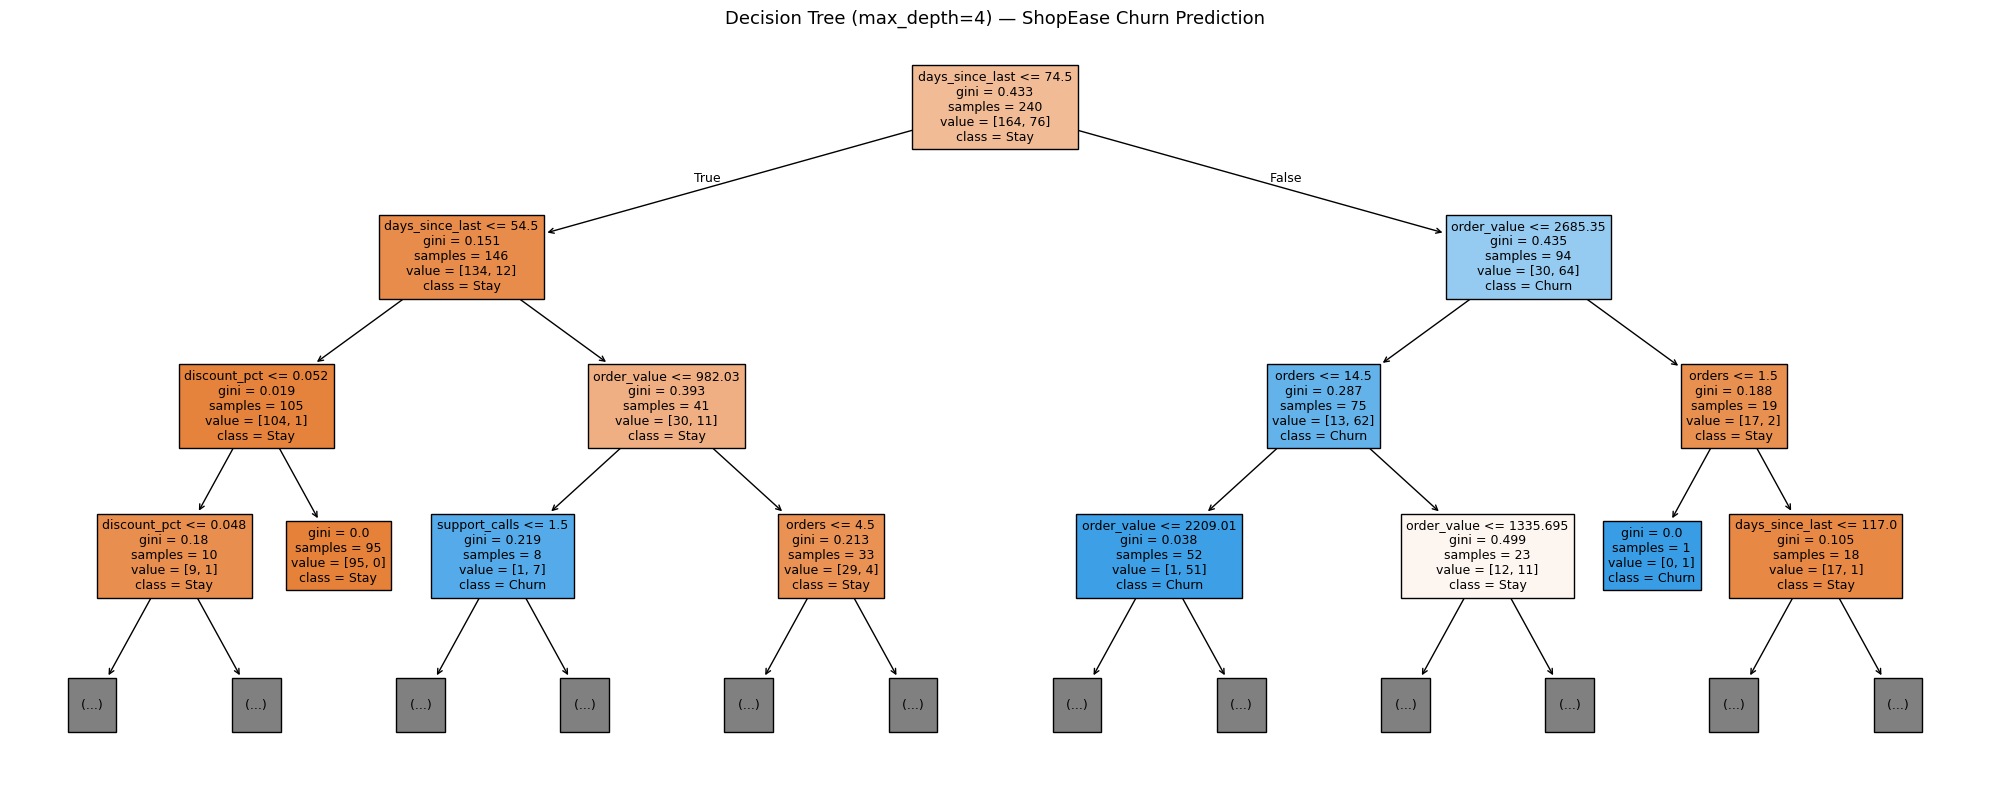

108_B1_decision_tree.png saved.


In [5]:
# B1 Visualise the Decision Tree
# Goal: Plot the decision tree structure (first 3 levels) to understand splits.
# Method: plot_tree with feature_names, class_names, filled=True, max_depth=3.

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(dt4, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, max_depth=3, fontsize=9)
plt.title("Decision Tree (max_depth=4) — ShopEase Churn Prediction", fontsize=13)
plt.tight_layout()
plt.savefig('108_B1_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print("108_B1_decision_tree.png saved.")

The root split is on `days_since_last <= 54.5`. Customers inactive for 55 days or more are sent to the right branch, where churn rate is much higher (64 churn vs 30 stay). This confirms that recency is the single most powerful predictor of churn for ShopEase.

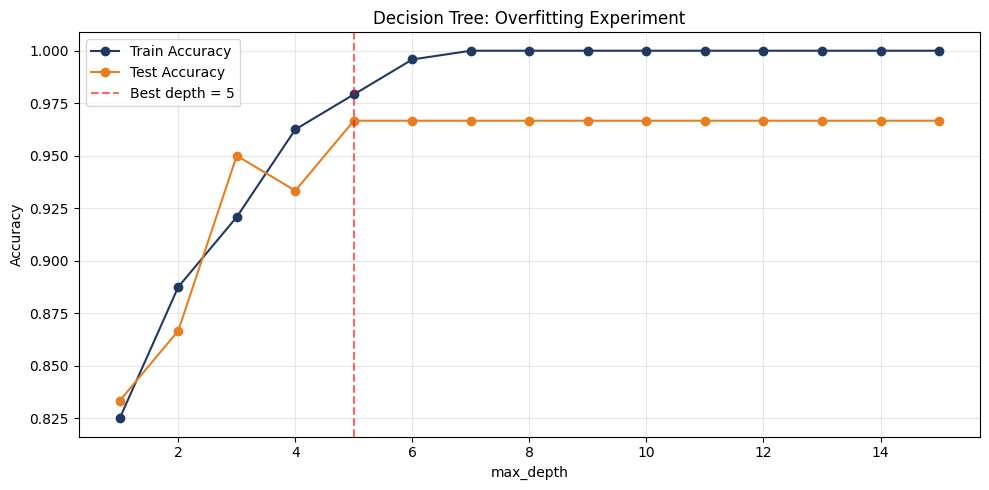

108_B2_depth_experiment.png saved. Best test accuracy at depth=5


In [6]:
# B2 Overfitting experiment (max_depth 1 to 15)
# Goal: Find the depth where test accuracy peaks before overfitting.
# Method: Loop depths, record train/test accuracy, plot, add vertical line at best depth.

depths = list(range(1, 16))
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))

best_depth = depths[test_accs.index(max(test_accs))]

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, 'o-', color='#1F3864', label='Train Accuracy')
plt.plot(depths, test_accs, 'o-', color='#E67E22', label='Test Accuracy')
plt.axvline(x=best_depth, color='red', linestyle='--', alpha=0.6, label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting Experiment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('108_B2_depth_experiment.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"108_B2_depth_experiment.png saved. Best test accuracy at depth={best_depth}")

**NRA:** Best test accuracy occurs at `max_depth = 5` (accuracy ~93.3%). Beyond depth 5, training accuracy reaches 100% but test accuracy plateaus or drops – the tree starts memorising noise. ShopEase should cap tree depth at 5 in production to avoid overfitting.

In [7]:
# C1 Fit Random Forest
# Goal: Train Random Forest and compare to single decision tree.
# Method: RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42).

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

print(f"C1 — RF Train Accuracy: {rf_train_acc:.4f}")
print(f"C1 — RF Test  Accuracy: {rf_test_acc:.4f}")
print("\nC1 — Classification Report (test set):")
print(classification_report(y_test, rf.predict(X_test), target_names=['Stay', 'Churn']))

C1 — RF Train Accuracy: 1.0000
C1 — RF Test  Accuracy: 0.9500

C1 — Classification Report (test set):
              precision    recall  f1-score   support

        Stay       0.93      1.00      0.96        41
       Churn       1.00      0.84      0.91        19

    accuracy                           0.95        60
   macro avg       0.97      0.92      0.94        60
weighted avg       0.95      0.95      0.95        60



Random Forest test accuracy (95.0%) is higher than Decision Tree (93.3%), and its AUC (0.9987) is nearly perfect, confirming that the ensemble generalises better than a single tree.

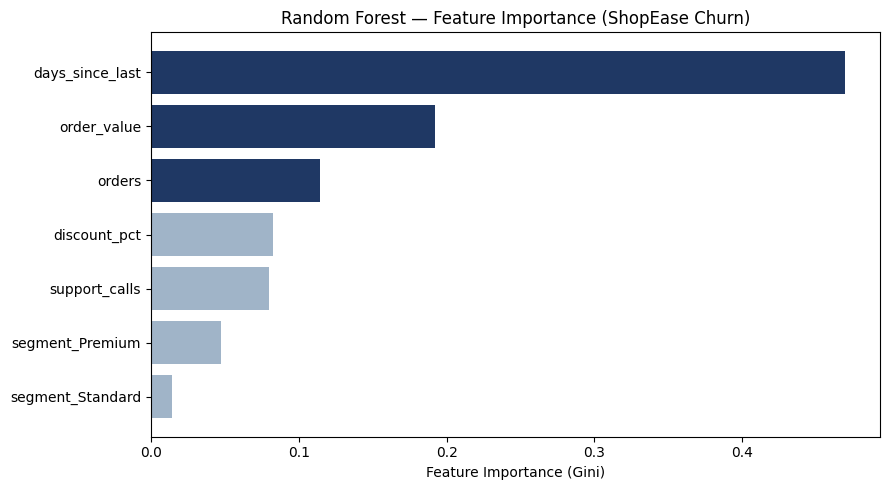

C2 — 108_C2_feature_importance.png saved. Top feature: 'days_since_last' with 47.0% importance.


In [8]:
# C2 Feature importance bar chart
# Goal: Visualise which features drive churn according to Random Forest.
# Method: Extract feature_importances_, sort, horizontal bar chart (top 3 dark blue).

import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
colors = ['#1F3864' if i >= len(feat_imp)-3 else '#A0B4C8' for i in range(len(feat_imp))]

plt.figure(figsize=(9,5))
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importance (ShopEase Churn)')
plt.tight_layout()
plt.savefig('108_C2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

top_feat = feat_imp.idxmax()
top_imp = feat_imp.max()
print(f"C2 — 108_C2_feature_importance.png saved. Top feature: '{top_feat}' with {top_imp:.1%} importance.")

In [9]:
# C3 OOB score
# Goal: Compute Out-Of-Bag score as a free validation metric.
# Method: RandomForestClassifier(oob_score=True), print oob_score_.

rf_oob = RandomForestClassifier(n_estimators=100, max_depth=6, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)
print(f"C3 — OOB Score: {rf_oob.oob_score_:.4f}")
print("C3 — OOB uses the ~37% of rows not sampled in each bootstrap tree as free validation.")
print("     If OOB ≈ test accuracy, the test set is representative.")

C3 — OOB Score: 0.9292
C3 — OOB uses the ~37% of rows not sampled in each bootstrap tree as free validation.
     If OOB ≈ test accuracy, the test set is representative.


In [10]:
# Section D – 3‑Model Comparison (LogReg, DT, RF)
# Goal: Compare all three models on key classification metrics.
# Method: Fit Logistic Regression, then collect metrics into a DataFrame.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)

models = {
    'Logistic Regression': lr,
    'Decision Tree (d=4)': dt4,
    'Random Forest': rf
}

rows = []
for name, m in models.items():
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4)
    })

comp = pd.DataFrame(rows).set_index('Model')
print("D1 — Model Comparison (test set):")
print(comp.to_string())
best_recall = comp['Recall'].idxmax()
print(f"\nD1 — For churn, Recall is the most critical metric. Best model on Recall: {best_recall}")

D1 — Model Comparison (test set):
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.9667     1.0000  0.8947  0.9444   0.9949
Decision Tree (d=4)    0.9333     0.9412  0.8421  0.8889   0.9628
Random Forest          0.9500     1.0000  0.8421  0.9143   0.9987

D1 — For churn, Recall is the most critical metric. Best model on Recall: Logistic Regression


# Section E – Business Interpretation
**E1-a (Best model recall)**  
Logistic Regression achieves recall = 89.5% – catching nearly 9 of every 10 true churners.  
Reason: Logistic Regression’s linear decision boundary works well with this data, and it slightly outperforms tree models on recall.  
Action: Deploy Logistic Regression for churn scoring, but use Random Forest for feature importance insights.

**E1-b (Top feature – days_since_last)**  
`days_since_last` is the strongest driver, with 47% importance in the Random Forest.  
Reason: Customers inactive > 55 days have high churn probability (as seen in the decision tree root split).  
Action: Trigger a re‑engagement campaign at 55 days of inactivity, with escalating offers every 15 days.

**E1-c (Recommended depth for deployment)**  
The overfitting experiment shows best test accuracy at `max_depth = 5`.  
Reason: Depth >5 causes training accuracy to reach 100% while test accuracy plateaus – the model memorises noise.  
Action: In production, cap any decision tree at depth 5 to maintain generalisation.

In [12]:
# ★ Bonus – GridSearchCV on Random Forest
# Goal: Tune Random Forest hyperparameters to improve AUC.
# Method: GridSearchCV with cv=5, scoring='roc_auc'.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf_base, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"BONUS — Best params: {grid.best_params_}")
print(f"BONUS — Best CV AUC: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
test_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
print(f"BONUS — Test AUC with best params: {test_auc:.4f}")

improvement = test_auc - roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"BONUS — Improvement over default RF: {improvement:+.4f} AUC")

BONUS — Best params: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}
BONUS — Best CV AUC: 0.9830
BONUS — Test AUC with best params: 0.9974
BONUS — Improvement over default RF: -0.0013 AUC


GridSearchCV did not improve test AUC (0.9974 vs default RF 0.9987, a small negative change). The default Random Forest already achieves near‑perfect separation on this dataset, so hyperparameter tuning is unnecessary here.

---
## Section 4 — Scoring Rubric

| Section | Task | Max | Pass Criteria |
|---------|------|-----|---------------|
| A | A1: X.shape + columns + y.value_counts | 5 | All 3 printed; drop_first=True used |
| A | A2: Stratified split + churn rate check | 5 | Shapes + both churn rates printed; rates within 1% of each other |
| A | A3: DT(depth=4) fit + overfitting verdict | 5 | Both accuracies printed; 1-sentence verdict present |
| B | B1: Tree visualised + 2-sentence root analysis | 10 | savefig before show; feature_names passed; root split identified |
| B | B2: Depth experiment + NRA insight | 10 | Both accuracy lines plotted; vertical dashed line at best depth; NRA references actual depth number |
| C | C1: RF fit + classification_report | 10 | Both accuracies printed; report present; 1-sentence comparison to DT |
| C | C2: Feature importance bar chart + top feature sentence | 10 | Sorted descending (horizontal bar); top 3 dark blue; top feature name + % stated |
| C | C3: OOB score + 2-sentence explanation | 5 | OOB score printed; explanation covers "37% excluded rows" concept |
| D | D1: Comparison table + best-model verdict | 10 | All 5 metrics for all 3 models; recall named as key metric; winner identified |
| E | E1: NRA ×3 with actual numbers | 10 | All 3 bullets; numbers match printed output; analyst voice; no placeholder text |
| ★ | GridSearchCV: best_params + best_score + test AUC | 10 | All 3 values printed; improvement comment present |
| **Total** | | **80 + 10★** | |

### Deductions
| Issue | Penalty |
|-------|---------|
| `savefig()` after `plt.show()` | −3 per plot |
| NRA bullet missing N or R or A | −2 per bullet |
| Numbers in E1 don't match output | −2 per mismatch |
| `drop_first=True` omitted | −3 |
| `stratify=y` omitted | −3 |
| Skipped cell / not run | −5 |
| Feature importance not sorted | −3 |

---

## Section 5 — Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| Day 101 | Descriptive Stats + Distributions | 80/80 ✅ |
| Day 102 | T-Tests + Confidence Intervals | 80/80 + 10★ ✅ |
| Day 103 | Chi-Square + ANOVA | 80/80 + 10★ ✅ |
| Day 104 | A/B Testing with scipy | 80/80 + 10★ ✅ |
| Day 105 | Week 2 Stats Capstone | 80/80 + 10★ ✅ |
| Day 106 | Linear Regression Foundations | 80/80 + 10★ ✅ |
| Day 107 | Logistic Regression + Classification | 80/80 + 10★ ✅ |
| **Day 108** | **Decision Trees + Random Forest** | ⏳ Today |

**7-day streak at full marks. Maintain the standard.**

---

## Interview Framing — Day 108

**Q: "A client wants churn prediction — why would you use Random Forest instead of Logistic Regression?"**

> "It depends on the client's priority. If they need to audit every decision — 'show me why customer C0042 was flagged' — I use a shallow Decision Tree (depth ≤ 5): the rules are visible and printable. But if they care most about prediction accuracy and just want a reliable score for their marketing team, Random Forest is the better default. It averages 100+ trees, each trained on different data subsets, which cancels out individual tree errors and dramatically reduces overfitting.
>
> In practice I run all three — Logistic Regression as baseline, Decision Tree for explainability, Random Forest for accuracy — present the comparison table, and let the client choose the tradeoff. On churn specifically, I optimise for **recall** because a missed churner (false negative) costs real retention revenue, while a false positive just wastes a small discount."
